In [50]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Literal,Annotated
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage, SystemMessage
import operator

In [51]:
generator_llm=ChatOpenAI(model='gpt-4o')
evaluator_llm=ChatOpenAI(model='gpt-4o-mini')
optimizer_llm=ChatOpenAI(model='gpt-4o')

In [52]:
#state
class TweetState(TypedDict):
    topic:str
    tweet:str
    evaluation:Literal['approved','needs_improvement']
    feedback:str
    iters:int
    max_iter: int # to stop inmfinite iterations
    tweet_history:Annotated[list[str],operator]
    feedback_history:Annotated[list[str],operator]

In [53]:
class Schema(BaseModel):
    evaluation:Literal['approved','needs_improvement']=Field(...,description='Final Evaluation result.')
    feedback:str=Field(...,description='constructive feedBACK FOR THE tweet')
    

In [54]:
structured_evaluator=evaluator_llm.with_structured_output(Schema)  

In [55]:
def generate_tweet(state: TweetState):
    messages = [
    SystemMessage(content="You are a funny and clever Twitter/X influencer."),
    
    HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english.
""")
]
    response=generator_llm.invoke(messages).content
    return {'tweet':response,'tweet_history':[response]}

In [56]:
def evaluate_tweet(state:TweetState):
    
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),

    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality - Is this fresh, or have you seen it a hundred times before?
2. Humor - Did it genuinely make you smile, laugh, or chuckle?
3. Punchiness - Is it short, sharp, and scroll-stopping?
4. Virality Potential - Would people retweet or share it?
5. Format - Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"
- feedback: One paragraph explaining the strengths and weaknesses
""")
]
    response=structured_evaluator.invoke(messages)
    return{'evaluation':response.evaluation,'feedback':response.feedback,'feedback_history':[response.feedback]} 
    

In [57]:
def optimize_tweet(state:TweetState):
    messages = [
    SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),

    HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
]
    response=optimizer_llm.invoke(messages).content
    iters=state['iters']+1
    return {'tweet':response,'tweet_history':[response]}

In [58]:
def route_evalution(state:TweetState):
    if state['evaluation']=='approved' or state['iters']>=state['max_iter']:
        return 'approved'
    else:
        return 'needs_improvement'


In [59]:
graph=StateGraph(TweetState)
graph.add_node('generate',generate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimizer',optimize_tweet)
graph.add_edge(START,'generate')
graph.add_edge('generate','evaluate')
graph.add_conditional_edges('evaluate',route_evalution , {'approved':END,'needs_improvement':'optimizer'})
graph.add_edge('optimizer','evaluate')
workflow=graph.compile()

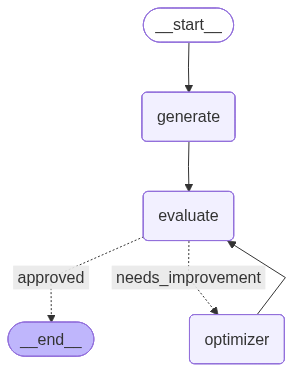

In [60]:
workflow

In [65]:
initial_state = {
    "topic": "Indian railways",
    "iters": 1,
    "max_iter": 5
}

workflow.invoke(initial_state)

{'topic': 'Indian railways',
 'tweet': 'Indian Railways: The only place where “running late” is a personality trait and a train schedule is more of a polite suggestion. 🚂😂 #NeverOnTime #ChaiTimeIsRailwayTime',
 'evaluation': 'approved',
 'feedback': "This tweet successfully captures the relatable nature of Indian Railways with a humorous twist. The originality shines through as the concept of 'running late' as a personality trait resonates on a personal level for many. The humor is evident and may induce smiles, while the punchy format is well-executed, making it an easy scroll-stopping read. Its catchy hashtags and light-hearted tone give it good virality potential, making it likely to be shared among users familiar with the context.",
 'iters': 1,
 'max_iter': 5,
 'tweet_history': ['Indian Railways: The only place where “running late” is a personality trait and a train schedule is more of a polite suggestion. 🚂😂 #NeverOnTime #ChaiTimeIsRailwayTime'],
 'feedback_history': ["This tweet